In [1]:
import tools

In [2]:
import time

In [3]:
vol1 = tools.ext.nib.load("../../../sub-1/ses-5/anat/sub-1_ses-5_acq-wipcs_T1w.nii.gz")

In [4]:
A1 = vol1.get_fdata()
aff1 = vol1.affine
print(A1.shape)

(160, 512, 512)


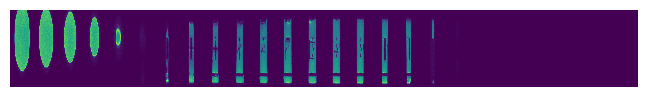

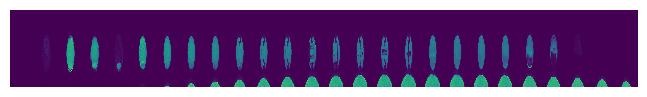

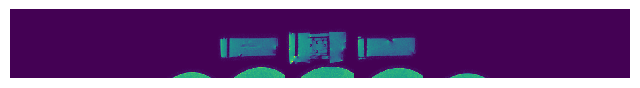

In [5]:
for mode in ["axial", "coronal", "sagittal"]: 
    tools.plot_slices(A1, mode, 20, decimate=3); 

In [6]:
A1r = A1[60:-60, 160:-160, 120:-180]

In [7]:
tools.ext.np.around(aff1, 2)

array([[ 1.000e+00, -0.000e+00,  1.000e-02, -8.067e+01],
       [ 0.000e+00,  2.300e-01, -1.000e-02, -8.653e+01],
       [-5.000e-02,  1.000e-02,  2.300e-01, -5.324e+01],
       [ 0.000e+00,  0.000e+00,  0.000e+00,  1.000e+00]])

In [8]:
tools.ext.np.sum(aff1 ** 2, 0) ** 0.5

array([  0.99999997,   0.23437499,   0.234375  , 129.73519413])

In [9]:
t1 = time.time()
(A2, aff2) = tools.compute_subresolution_A1_aligned(
    # A1, (0.391, 0.391, 0.391), (2.5, 2.5, 2.5), nrand=1000)
    A1r, (1, 0.234375, 0.234375), (1.25, 1.25, 1.25), nrand=1000)
t2 = time.time()
print(t2 - t1)

28.33362913131714


In [10]:
A2.shape

(33, 37, 40)

In [12]:
(A0, aff0) = tools.load_template("../templates/template-phantom-mri_resolution-1250.nii.gz")

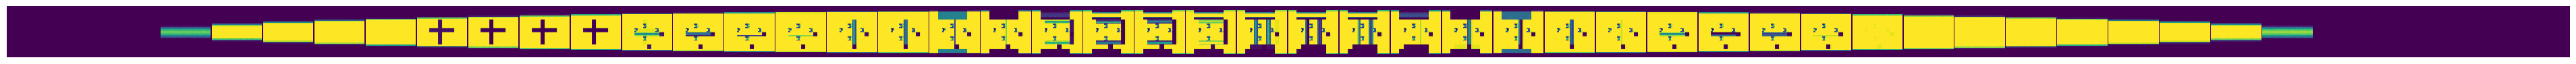

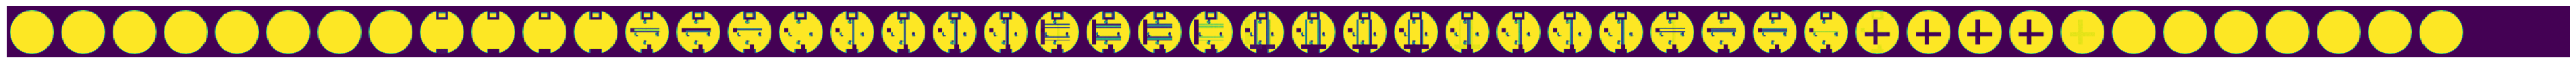

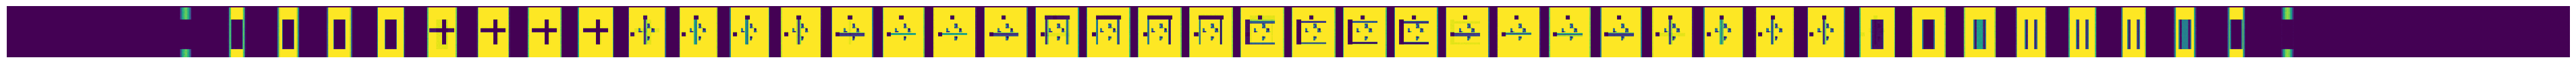

In [13]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A0, mode); 

In [14]:
A0.shape

(49, 49, 49)

In [15]:
A0r = A0[8:-8, 8:-8, 8:-8]
print(A0r.shape)
patterns = tools.compute_patterns(A0r)

(33, 33, 33)


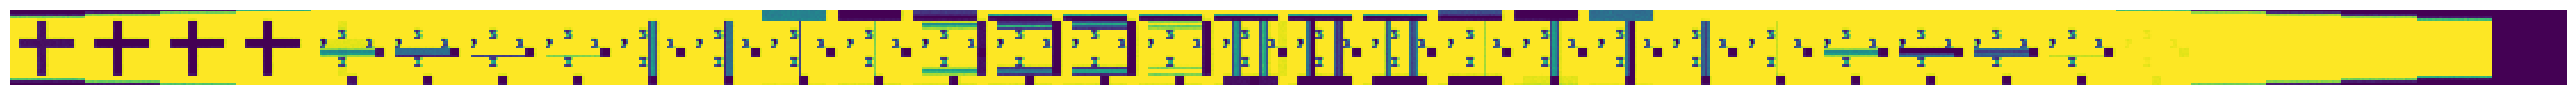

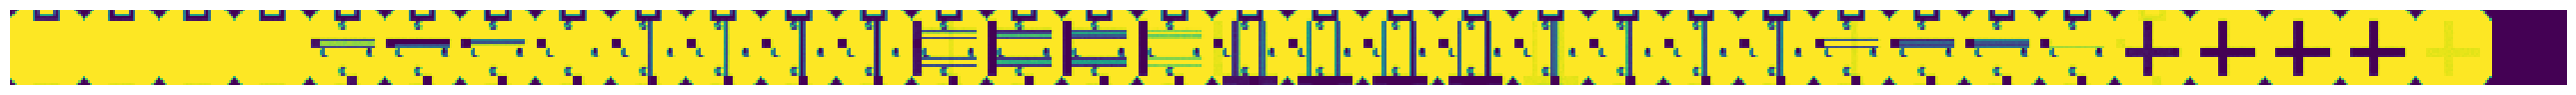

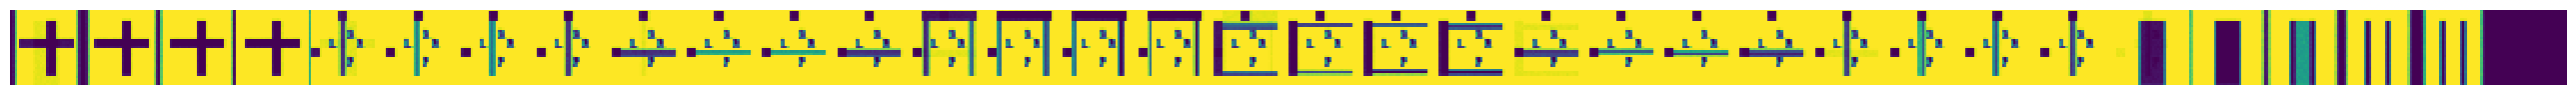

In [16]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A0r, mode); 

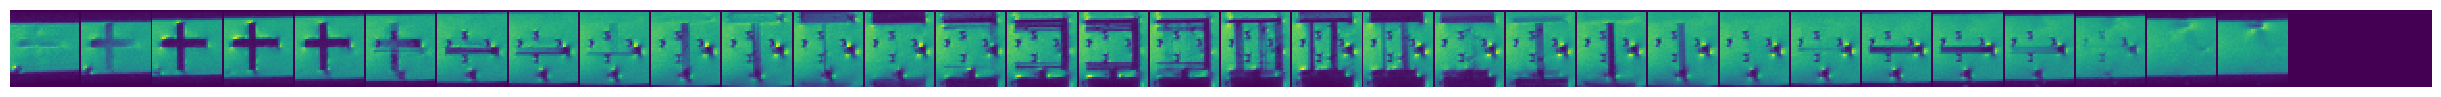

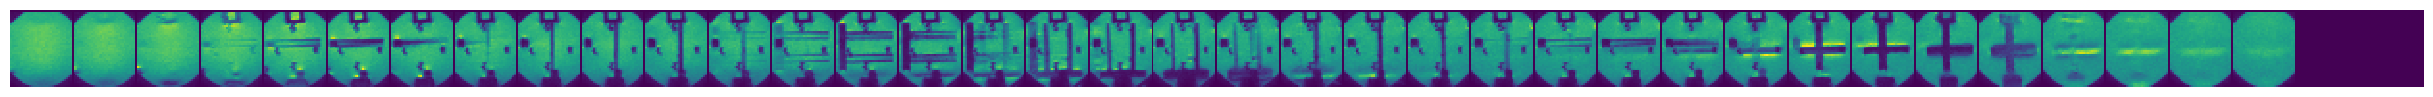

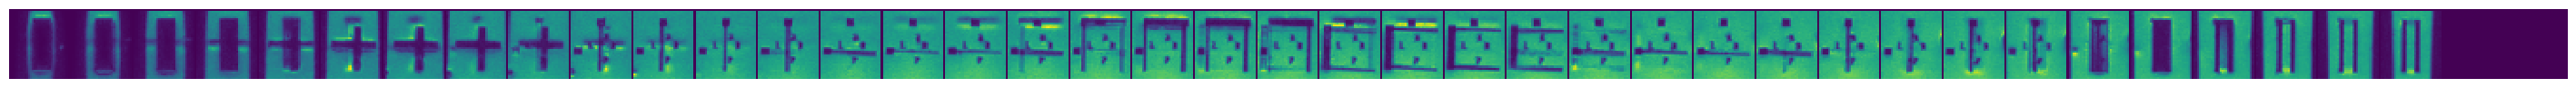

In [17]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A2, mode); 

In [18]:
print(A0r.shape, A2.shape, tools.ext.np.min(A2), tools.ext.np.max(A2))

(33, 33, 33) (33, 37, 40) 0.0 12762.13840578264


In [19]:
res = {}
t1 = time.time()
A2c = tools.ext.np.clip(A2, 0, 12755)
for k in patterns: 
    Ak = patterns[k]
    ck = tools.compute_A_inside_B_best_translation(Ak, A2c)
    res[k] = {"i": ck[0], "j": ck[1], "k": ck[2], "c": ck[3]}
t2 = time.time()
print(t2 - t1)
df1 = tools.ext.pd.DataFrame(res)
df2 = df1.T
df3 = df2.sort_values(by="c")

40.81997466087341


In [20]:
df3

,i,j,k,c
"True_False_False_(1, 2, 0)",0.0,1.0,5.0,0.842064
"False_False_False_(1, 2, 0)",0.0,2.0,5.0,0.844863
"True_False_True_(1, 2, 0)",0.0,0.0,4.0,0.845522
"False_False_True_(1, 2, 0)",0.0,2.0,5.0,0.847432
"True_False_True_(0, 2, 1)",0.0,3.0,5.0,0.848740
"False_False_True_(0, 2, 1)",0.0,1.0,4.0,0.852065
"True_True_True_(0, 2, 1)",0.0,0.0,5.0,0.855605
"True_False_False_(0, 2, 1)",0.0,2.0,5.0,0.856857
"False_True_True_(1, 2, 0)",0.0,1.0,5.0,0.857290
"False_False_False_(0, 2, 1)",0.0,2.0,5.0,0.858009


In [21]:
print(tools.ext.np.around(aff1, 3))

[[ 9.9900e-01 -0.0000e+00  1.3000e-02 -8.0669e+01]
 [ 2.0000e-03  2.3400e-01 -7.0000e-03 -8.6534e+01]
 [-5.4000e-02  7.0000e-03  2.3400e-01 -5.3241e+01]
 [ 0.0000e+00  0.0000e+00  0.0000e+00  1.0000e+00]]


In [22]:
(flips1, orientations1) = tools.compute_flips_permutations(aff1)
print(flips1, orientations1)

[False, False, False] [np.int64(0), np.int64(1), np.int64(2)]


In [23]:
(flips2, orientations2) = ([False, False, False], [0, 1, 2])

In [24]:
tools.test_flips_orientations(flips1, flips2, orientations1, orientations2)

'......'